# (01) Cadena Data (Michael's Demo)

Standalone ConvNet training on Cadena V1 data with held-out FEV reporting.

In [1]:
import importlib
from mcfe.utils.plotting import *

os.environ.setdefault('CUDA_VISIBLE_DEVICES', '2,3')

module_file_path = '/home/hadi/Dropbox/git/_CadenaV1/modules.py'
spec = importlib.util.spec_from_file_location('modules_file', module_file_path)
modules_file = importlib.util.module_from_spec(spec)
sys.modules['modules_file'] = modules_file
spec.loader.exec_module(modules_file)

DEFAULT_DATA_PATH = modules_file.DEFAULT_DATA_PATH
build_dataloaders = modules_file.build_dataloaders
fit_sgd = modules_file.fit_sgd
get_dataset_specs = modules_file.get_dataset_specs
get_train_val_datasets = modules_file.get_train_val_datasets
pick_device = modules_file.pick_device
run_eval = modules_file.run_eval

In [2]:
print('CUDA_VISIBLE_DEVICES =', os.environ.get('CUDA_VISIBLE_DEVICES'))
print('Dataset path =', DEFAULT_DATA_PATH)
print('CUDA available =', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Visible GPUs =', torch.cuda.device_count())
    print('GPU[0] =', torch.cuda.get_device_name(0))

CUDA_VISIBLE_DEVICES = 2,3

Dataset path = /home/hadi/Datasets/CadenaV1/cadena_ploscb_data.pkl

CUDA available = True

Visible GPUs = 2

GPU[0] = NVIDIA RTX 6000 Ada Generation

In [3]:
spec = get_dataset_specs()
print('Neurons:', spec.num_neurons)
print('Total images:', spec.num_images_total)
print('First split train images:', spec.train_images_first_split)
print('First split val images:', spec.val_images_first_split)
print('Repetition distribution (trials/image by neuron):', spec.unique_repetition_counts)

train_ds, val_ds = get_train_val_datasets()
device = pick_device()
train_ds.to(device)
val_ds.to(device)
train_dl, val_dl = build_dataloaders(train_ds, val_ds, batch_size=1_000)

print('Device:', device)
print('Train samples:', len(train_ds), 'Val samples:', len(val_ds))

Neurons: 166

Total images: 7250

First split train images: 5800

First split val images: 1450

Repetition distribution (trials/image by neuron):
{2: 51, 4: 115}

Device: cuda:1

Train samples: 18560 Val samples: 4640

In [4]:
from mcfe.main.load_model import load_model
from mcfe.common.helpers import print_num_params

## my conv (deep)

In [5]:
dims = list(train_ds[0]['stim'].shape)
num_neurons = train_ds[0]['robs'].shape[0]

print(f"dims = {dims},\tnum_neurons = {num_neurons}")

dims = [1, 40, 40],     num_neurons = 166

In [6]:
latent_channels = 256
latent_pixels = 10

model = modules_file.ConvNetHadi(
    dims=dims,
    latent_channels=latent_channels,
    latent_pixels=latent_pixels,
    num_neurons=num_neurons,
    base_channels=32,
    use_se=True,
    deep=True,
).to(device)

In [7]:
print_num_params(model)

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
| ConvNetHadi |  441.8 K   |
|     ———     |    ———     |
|     net     |  323.4 K   |
|   readout   |  118.4 K   |
+-------------+------------+

In [8]:
lr = 1e-3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=0.1,
)

In [9]:
%%time


best_state, losses, vlosses = fit_sgd(
    model,
    train_dl,
    val_dl,
    optimizer,
    max_epochs=1000,
    patience=20,
    laplace_coeff=0.0,
    min_lr=lr / 10,
)
model.load_state_dict(best_state)

/home/hadi/Dropbox/git/_CadenaV1/modules.py:305: RuntimeWarning: Degrees of freedom <= 0 for slice.
  obs_var = torch.nanmean(torch.tensor(np.nanvar(resp_n.numpy(), axis=0, ddof=1)))


Epoch 0, lr: 0.000021, Validation Loss: 2.516765594482422
New best model
Epoch 10, lr: 0.000221, Validation Loss: 0.0008521754061803222
Epoch 20, lr: 0.000421, Validation Loss: -0.03522922471165657
Epoch 30, lr: 0.000620, Validation Loss: -0.2002895325422287
Epoch 40, lr: 0.000820, Validation Loss: -0.3451235890388489
New best model


/home/hadi/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 50, lr: 0.001000, Validation Loss: -0.4194369614124298
New best model
Epoch 60, lr: 0.001000, Validation Loss: -0.44988980889320374
Epoch 70, lr: 0.000999, Validation Loss: -0.4351850748062134
Epoch 80, lr: 0.000998, Validation Loss: -0.4442605972290039
Stopping early due to no improvement
CPU times: user 7min 17s, sys: 820 ms, total: 7min 17s
Wall time: 2min 45s


<All keys matched successfully>

Number of neurons: 166

Trials per image (repeat-count distribution):
{2: 51, 4: 115}

Held-out FEV mean: 0.46396347880363464

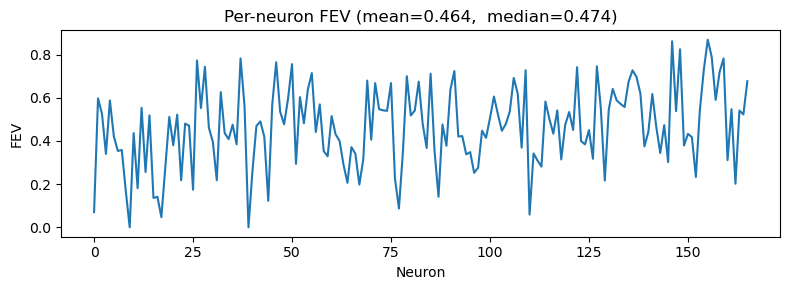

In [10]:
fev, var_explained, explainable_var, mse, total_variance = run_eval(model, val_dl)
fev_mean = torch.nanmean(fev).item()
fev_all = torch.nan_to_num(fev.detach().cpu(), nan=0.0).clip(min=0)

print('Number of neurons:', spec.num_neurons)
print('Trials per image (repeat-count distribution):', spec.unique_repetition_counts)
print('Held-out FEV mean:', fev_mean)

plt.figure(figsize=(8, 3))
plt.plot(fev_all)
plt.title(f'Per-neuron FEV (mean={fev_mean:.3f},  median={np.nanmedian(fev_all):0.3f})')
plt.xlabel('Neuron')
plt.ylabel('FEV')
plt.tight_layout()
plt.show()

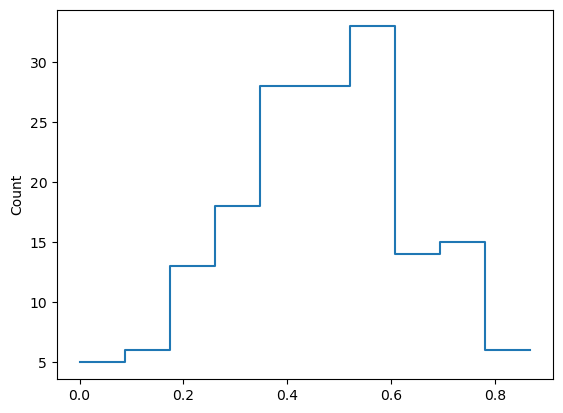

In [11]:
histplot(fev_all);

## my conv (linear)

In [27]:
dims = list(train_ds[0]['stim'].shape)
num_neurons = train_ds[0]['robs'].shape[0]

print(f"dims = {dims},\tnum_neurons = {num_neurons}")

dims = [1, 40, 40],     num_neurons = 166

In [28]:
latent_channels = 256
latent_pixels = 11

model = modules_file.ConvNetHadi(
    dims=dims,
    latent_channels=latent_channels,
    latent_pixels=latent_pixels,
    num_neurons=num_neurons,
    base_channels=32,
    use_se=True,
    deep=False,
).to(device)

In [29]:
print_num_params(model)

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
| ConvNetHadi |  151.2 K   |
|     ———     |    ———     |
|     net     |   25.9 K   |
|   readout   |  125.3 K   |
+-------------+------------+

In [30]:
print(model.net)

Conv2d(1, 256, kernel_size=(10, 10), stride=(3, 3))

In [31]:
lr = 1e-3

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=lr,
    weight_decay=0.1,
)

In [32]:
%%time


best_state, losses, vlosses = fit_sgd(
    model,
    train_dl,
    val_dl,
    optimizer,
    max_epochs=1000,
    patience=20,
    laplace_coeff=0.0,
    min_lr=lr / 10,
)
model.load_state_dict(best_state)

/home/hadi/Dropbox/git/_CadenaV1/modules.py:305: RuntimeWarning: Degrees of freedom <= 0 for slice.
  obs_var = torch.nanmean(torch.tensor(np.nanvar(resp_n.numpy(), axis=0, ddof=1)))


Epoch 0, lr: 0.000021, Validation Loss: 2.535613536834717
New best model
Epoch 10, lr: 0.000221, Validation Loss: 0.172164648771286
New best model
Epoch 20, lr: 0.000421, Validation Loss: -0.08768348395824432
New best model
Epoch 30, lr: 0.000620, Validation Loss: -0.12579092383384705
New best model
Epoch 40, lr: 0.000820, Validation Loss: -0.12193469703197479


/home/hadi/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 50, lr: 0.001000, Validation Loss: -0.10453908145427704
Stopping early due to no improvement
CPU times: user 3min 20s, sys: 315 ms, total: 3min 20s
Wall time: 32.8 s


<All keys matched successfully>

Number of neurons: 166

Trials per image (repeat-count distribution):
{2: 51, 4: 115}

Held-out FEV mean: 0.12765207886695862

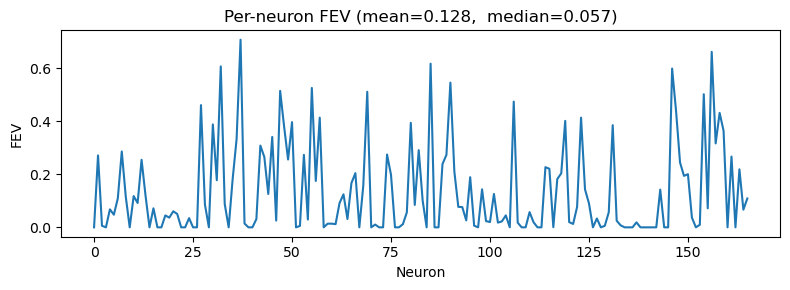

In [33]:
fev, var_explained, explainable_var, mse, total_variance = run_eval(model, val_dl)
fev_mean = torch.nanmean(fev).item()
fev_all = torch.nan_to_num(fev.detach().cpu(), nan=0.0).clip(min=0)

print('Number of neurons:', spec.num_neurons)
print('Trials per image (repeat-count distribution):', spec.unique_repetition_counts)
print('Held-out FEV mean:', fev_mean)

plt.figure(figsize=(8, 3))
plt.plot(fev_all)
plt.title(f'Per-neuron FEV (mean={fev_mean:.3f},  median={np.nanmedian(fev_all):0.3f})')
plt.xlabel('Neuron')
plt.ylabel('FEV')
plt.tight_layout()
plt.show()

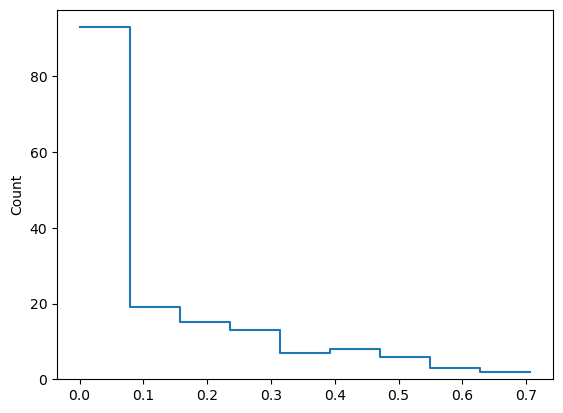

In [34]:
histplot(fev_all);

## fit Jake's model

In [12]:
dims = list(train_ds[0]['stim'].shape)
num_neurons = train_ds[0]['robs'].shape[0]

model = modules_file.ConvNet(dims=dims, output_channels=num_neurons, sigma=0.1).to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=0.1,
)

In [13]:
from mcfe.common.helpers import print_num_params

print_num_params(model)

+-------------+------------+
| Module Name | Num Params |
+-------------+------------+
|   ConvNet   |  246.0 K   |
|     ———     |    ———     |
|     net     |  127.7 K   |
|   readout   |  118.4 K   |
+-------------+------------+

In [14]:
%%time


best_state, losses, vlosses = fit_sgd(
    model,
    train_dl,
    val_dl,
    optimizer,
    max_epochs=200,
    patience=20,
    laplace_coeff=0.1,
)
model.load_state_dict(best_state)

/home/hadi/Dropbox/git/_CadenaV1/modules.py:295: RuntimeWarning: Degrees of freedom <= 0 for slice.
  obs_var = torch.nanmean(torch.tensor(np.nanvar(resp_n.numpy(), axis=0, ddof=1)))


Epoch 0, LR: 0.000168, Validation Loss: 1979.427490234375
New best model
Epoch 1, LR: 0.000334, Validation Loss: 575.0392456054688
New best model
Epoch 2, LR: 0.000501, Validation Loss: 63.87322998046875
New best model
Epoch 3, LR: 0.000667, Validation Loss: 3.693742036819458
New best model
Epoch 4, LR: 0.000834, Validation Loss: 0.6995421648025513
New best model


/home/hadi/anaconda3/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


Epoch 5, LR: 0.001000, Validation Loss: 0.19936513900756836
New best model
Epoch 6, LR: 0.001000, Validation Loss: 0.015290189534425735
New best model
Epoch 7, LR: 0.000999, Validation Loss: -0.05756127089262009
New best model
Epoch 8, LR: 0.000998, Validation Loss: -0.10106614977121353
New best model
Epoch 9, LR: 0.000997, Validation Loss: -0.1257004588842392
New best model
Epoch 10, LR: 0.000995, Validation Loss: -0.15615405142307281
New best model
Epoch 11, LR: 0.000993, Validation Loss: -0.15673241019248962
New best model
Epoch 12, LR: 0.000991, Validation Loss: -0.20177286863327026
New best model
Epoch 13, LR: 0.000988, Validation Loss: -0.2165473848581314
New best model
Epoch 14, LR: 0.000985, Validation Loss: -0.21852178871631622
New best model
Epoch 15, LR: 0.000981, Validation Loss: -0.24608729779720306
New best model
Epoch 16, LR: 0.000977, Validation Loss: -0.2623971104621887
New best model
Epoch 17, LR: 0.000973, Validation Loss: -0.27697187662124634
New best model
Epoch 18

<All keys matched successfully>

## eval

Number of neurons: 166

Trials per image (repeat-count distribution):
{2: 51, 4: 115}

Held-out FEV mean: 0.4514051675796509

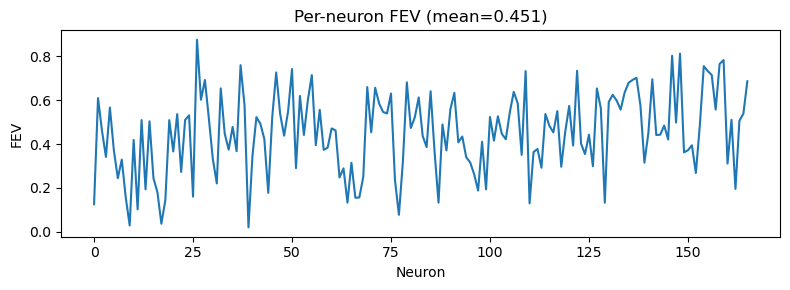

In [19]:
fev, var_explained, explainable_var, mse, total_variance = run_eval(model, val_dl)
fev_mean = torch.nanmean(fev).item()
fev_all = torch.nan_to_num(fev.detach().cpu(), nan=0.0).clip(min=0)

print('Number of neurons:', spec.num_neurons)
print('Trials per image (repeat-count distribution):', spec.unique_repetition_counts)
print('Held-out FEV mean:', fev_mean)

plt.figure(figsize=(8, 3))
plt.plot(fev_all)
plt.title(f'Per-neuron FEV (mean={fev_mean:.3f})')
plt.xlabel('Neuron')
plt.ylabel('FEV')
plt.tight_layout()
plt.show()

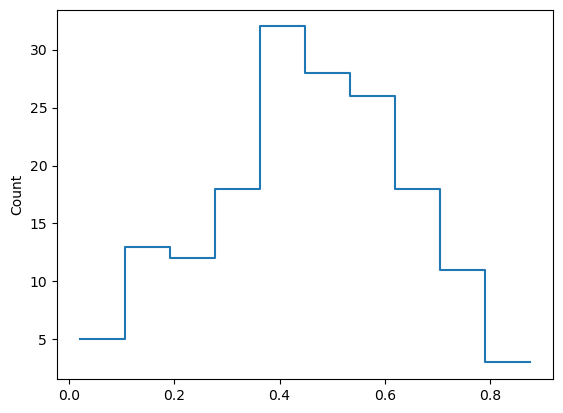

In [20]:
histplot(fev_all);